In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis  import *
import config
from config import SPE1_PICKLE_ROOT, PRIORITY_CELLS


In [2]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

## Load data

One row per (cell × spike_feature × cluster_pair). Columns: nRMSE, cos_sim, num_clusters, temporal drift, and all metadata.

In [3]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [4]:
df_master

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
0,c1,Juxta,IC,PC,843.9,False,False,peak_amp,3,Low-High,0.084226,0.839597,-0.792646,0.000000e+00,1.0
1,c1,Juxta,IC,PC,843.9,False,False,peak_sharpness,3,Low-High,0.070893,0.941558,-0.627883,1.313414e-187,1.0
2,c1,Juxta,IC,PC,843.9,False,False,exp_lambda,3,Low-High,0.092695,0.794549,-0.527016,1.731403e-122,1.0
3,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-Mid,0.042741,0.998670,0.317826,2.667009e-41,1.0
4,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-High,0.039477,0.997466,0.317826,2.667009e-41,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-High,0.085761,0.875685,0.398502,4.885509e-256,1.0
146,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Mid-High,0.045825,0.970138,0.398502,4.885509e-256,1.0
147,c45,Juxta,VC,PC,1137.0,False,True,log_isi,3,Low-High,0.047321,0.968537,-0.100840,9.668021e-17,1.0
148,c46,Juxta,VC,PC,1039.7,False,True,exp_lambda,2,Low-High,0.024863,0.979165,-0.056060,3.679477e-06,1.0


In [5]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



## Dataset overview

Full master table — all cells, all spike features, all cluster pairs.

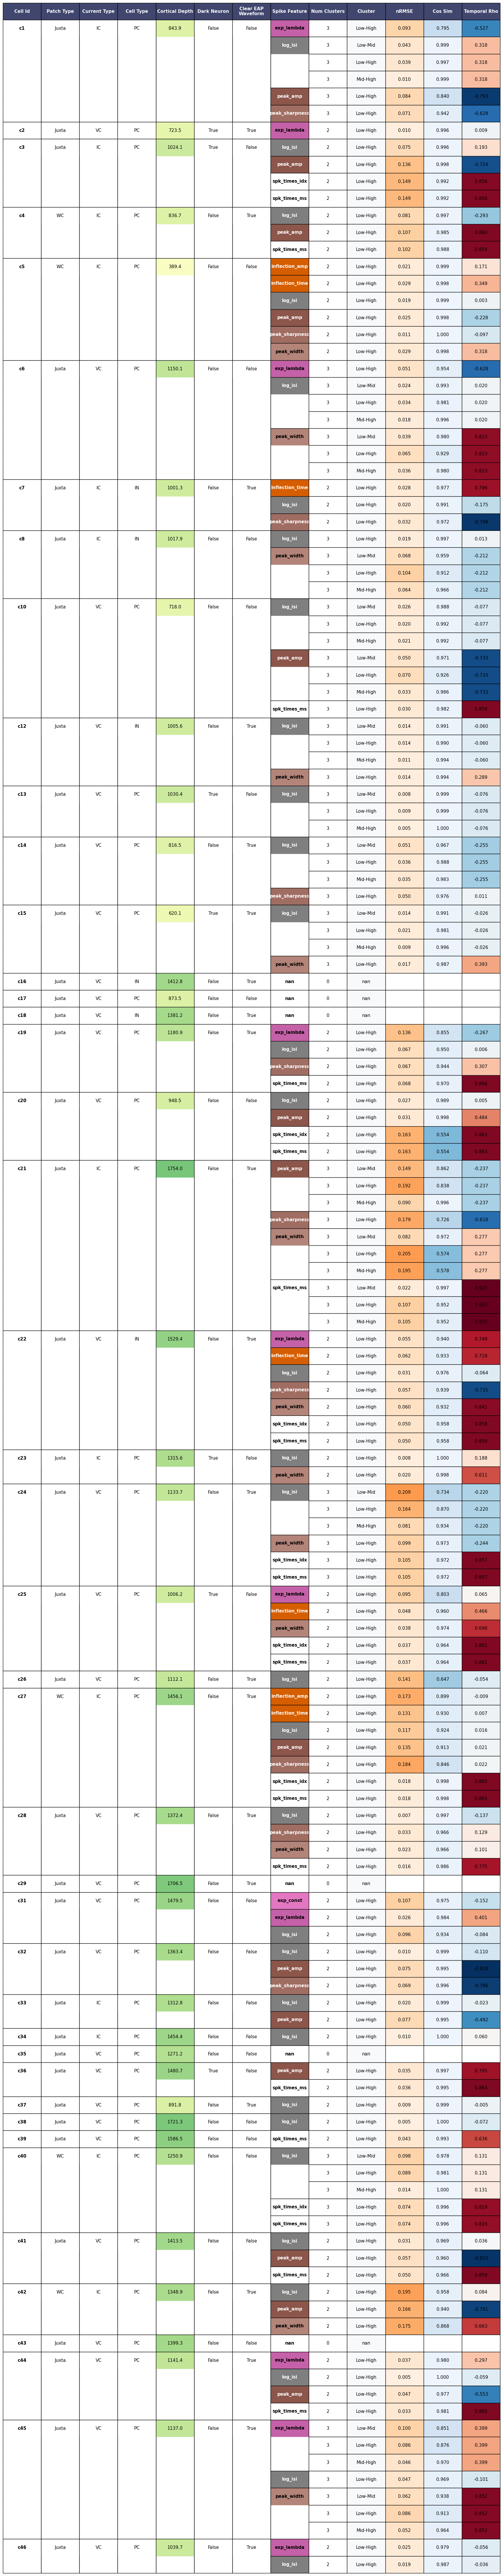

In [6]:

gen_table_fig(df_master)


## Are clustering results driven by biology or recording conditions?

Before interpreting waveform cluster differences as biology, we need to rule out recording artefacts. Three checks: metadata vs cluster quality, which features cluster at all, and temporal drift.

## A. Does recording metadata predict cluster quality?

Spearman ρ between each metadata variable (cell type, patch type, depth, etc.) and clustering metrics (nRMSE, cos_sim, num_clusters). BH-FDR corrected. A significant association = potential confound.

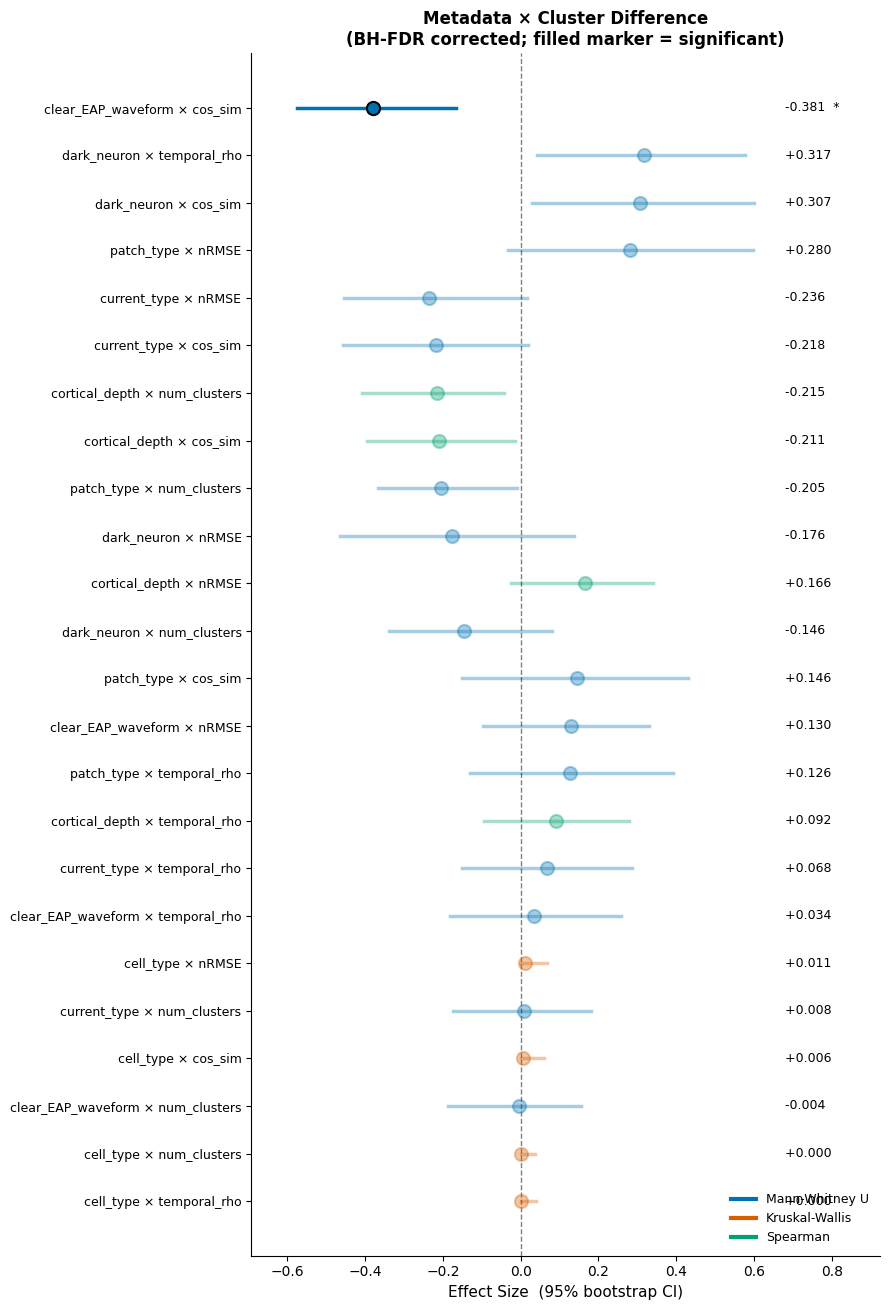


1/24 pairs significant after BH-FDR (α=0.05, n_bootstrap=1000):
  clear_EAP_waveform     × cos_sim        | rank-biserial r = -0.381  95% CI [-0.576, -0.167]  p_fdr=1.397e-02 *


,Metadata,Feature,test,effect_label,Effect_Size,ci_lo,ci_hi,p_raw,p_fdr,significant,Significance,p-value
0,clear_EAP_waveform,cos_sim,Mann-Whitney U,rank-biserial r,-0.381,-0.576,-0.167,0.000582,0.013973,True,*,1.40e-02


In [7]:
sig_meta_clust_feats = analyze_cross_correlations(df_master)
sig_meta_clust_feats

Significant correlations here are flags — they mean clustering quality is tied to how you recorded the cell, not just biology. The most common confound is patch type: WC recordings may show more waveform variability due to dialysis effects.

Significant metadata–cluster pairs plotted below.

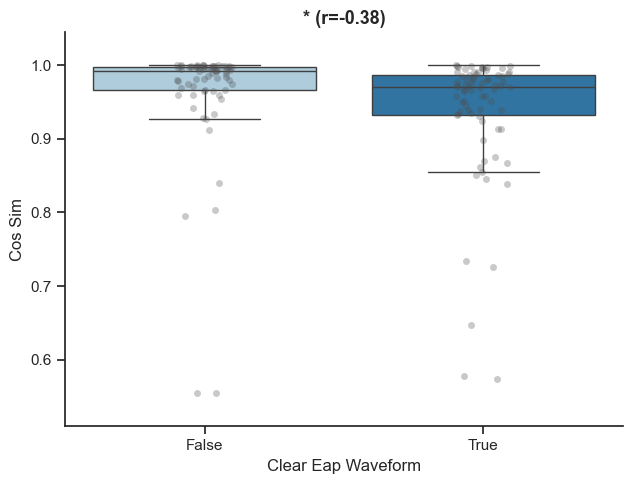

In [8]:
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)



## B. Which spike features cluster and how reliably?

Prevalence = fraction of cells where that feature shows multimodal clustering. Also reports mean cluster quality (nRMSE, cos_sim) per feature across cells.

In [9]:
#Aggregate cluster metrics and prevalence by spike feature
spk_feat_prevalence = quantify_spk_feature_prevalence(df_master)


In [10]:
spk_feat_prevalence

,spike_feature,n_cells_with_feature,prevalence_pct,num_clusters,cos_sim,nRMSE,temporal_rho
4,log_isi,32,74.418605,2.580000,0.971779,0.043493,-0.026916
9,spk_times_ms,16,37.209302,2.333333,0.955322,0.067145,0.851840
5,peak_amp,14,32.558140,2.388889,0.954204,0.086735,-0.329808
7,peak_width,13,30.232558,2.714286,0.921577,0.073064,0.423504
1,exp_lambda,10,23.255814,2.416667,0.915222,0.063225,0.103214
6,peak_sharpness,10,23.255814,2.300000,0.930631,0.075236,-0.319410
8,spk_times_idx,7,16.279070,2.285714,0.919327,0.085072,0.854192
3,inflection_time,5,11.627907,2.000000,0.959532,0.059581,0.467339
2,inflection_amp,2,4.651163,2.000000,0.948892,0.096923,0.080990
0,exp_const,1,2.325581,2.000000,0.974960,0.106504,-0.151539


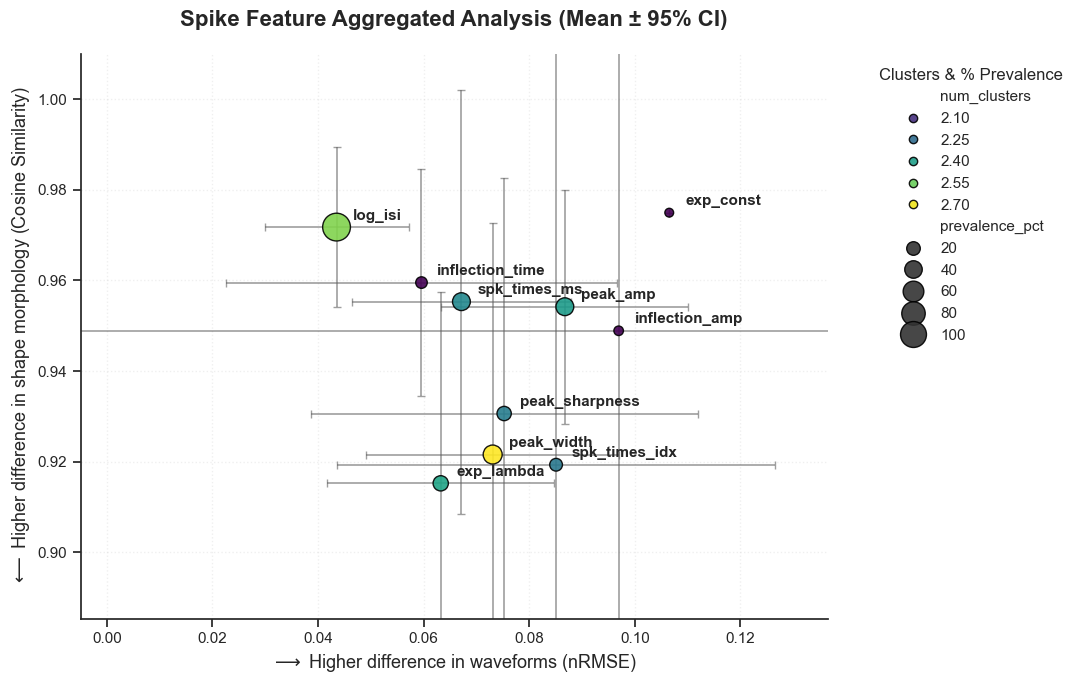

In [11]:
plot_aggregated_spike_feat(df_master)


Features with high prevalence (>50% of cells) and high mean nRMSE are your strongest candidates for biological waveform variability. Low prevalence features may just be splitting noise. Check whether the high-prevalence features overlap with what's driving the LFP effects in the sliding window notebook.

Does metadata predict *which* spike feature clusters? Chi-square (categorical) and Kruskal-Wallis (continuous) tests per feature.

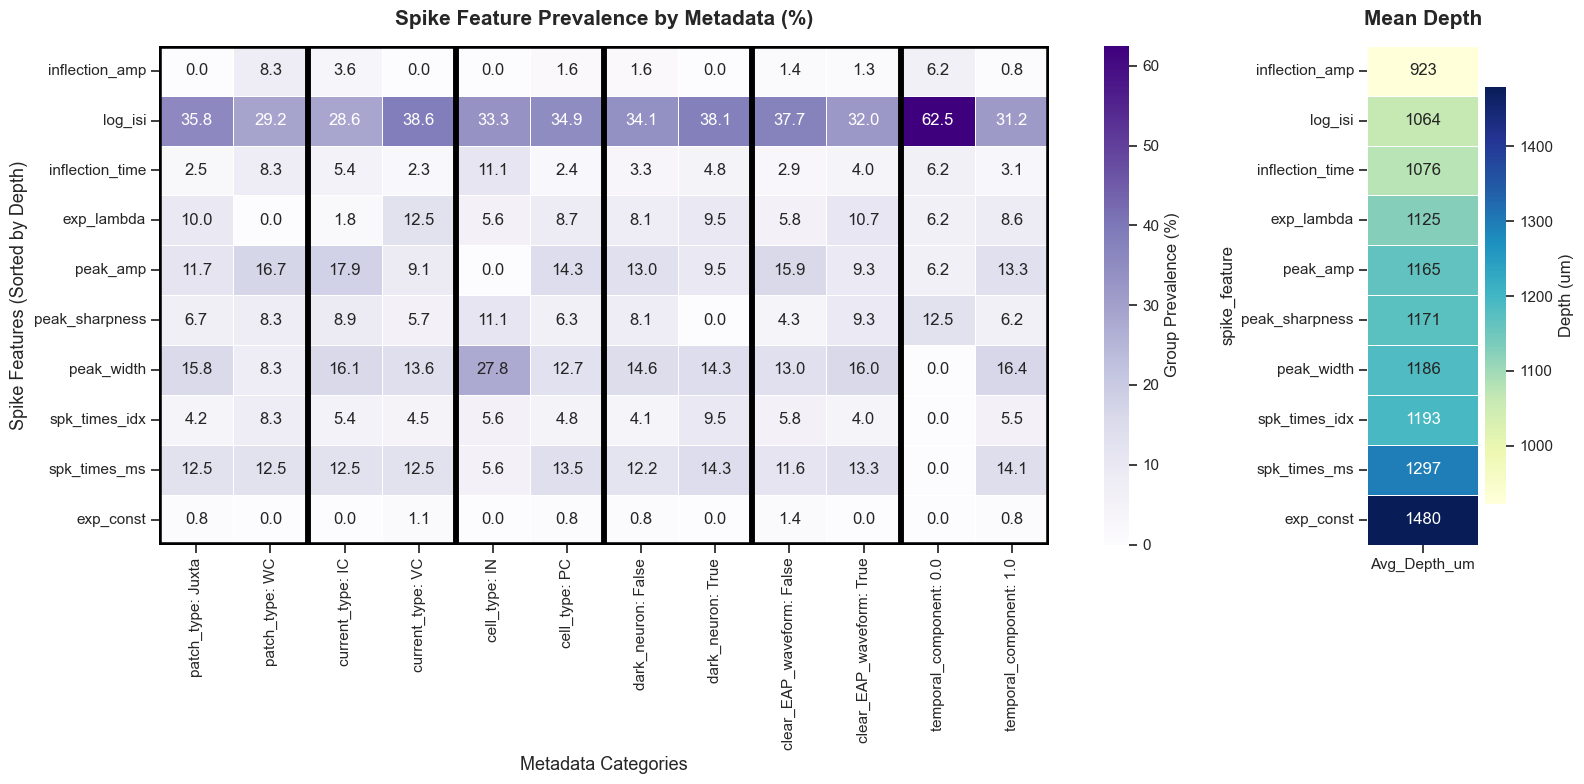

In [12]:
plot_meta_spk_feature_dependency(df_master)

In [13]:

_ = stat_test_metadata_dependency(df_master)

----------------------------------------
METADATA DEPENDENCY ANALYSIS (Chi-Square)
----------------------------------------
patch_type           | p = 5.225e-02 (ns)
current_type         | p = 1.521e-01 (ns)
cell_type            | p = 3.158e-01 (ns)
dark_neuron          | p = 9.242e-01 (ns)
clear_EAP_waveform   | p = 7.738e-01 (ns)
temporal_rho         | p = 1.390e-09 (***)
temporal_p           | p = 4.678e-08 (***)
temporal_component   | p = 9.676e-02 (ns)
----------------------------------------


If a metadata variable predicts which feature clusters, that feature's clusters may reflect recording conditions rather than biology — treat with caution in the LFP analysis.

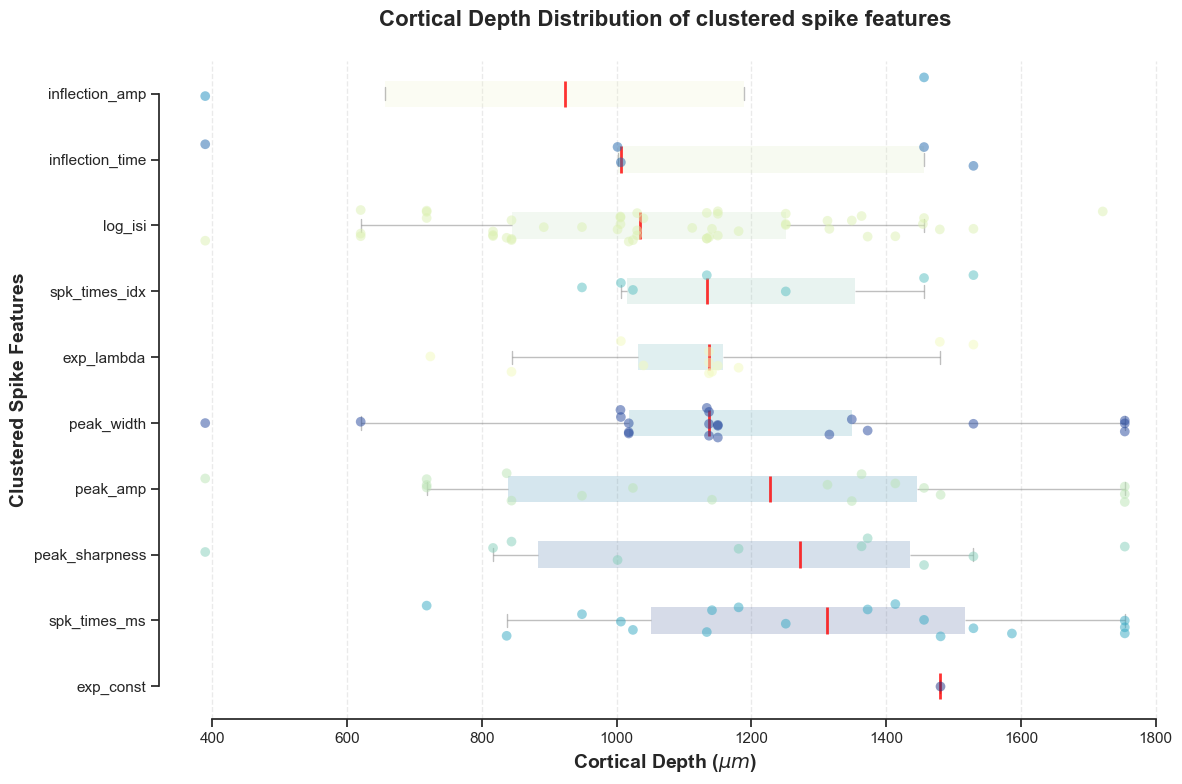

In [14]:
plot_feature_depth_distribution(df_master)

In [15]:
_ =stat_test_depth_stratification(df_master)

----------------------------------------
DEPTH STRATIFICATION ANALYSIS
----------------------------------------
Kruskal-Wallis H-stat: 9.410
p-value: 4.003e-01

No significant depth stratification found.
----------------------------------------


Depth stratification would suggest cortical-layer organisation of waveform variability. No stratification = waveform variability is distributed across layers.

## C. Largest waveform differences

Top 30 (cell × spike_feature) pairs by nRMSE — these are the cells and features with the most distinct waveform clusters.

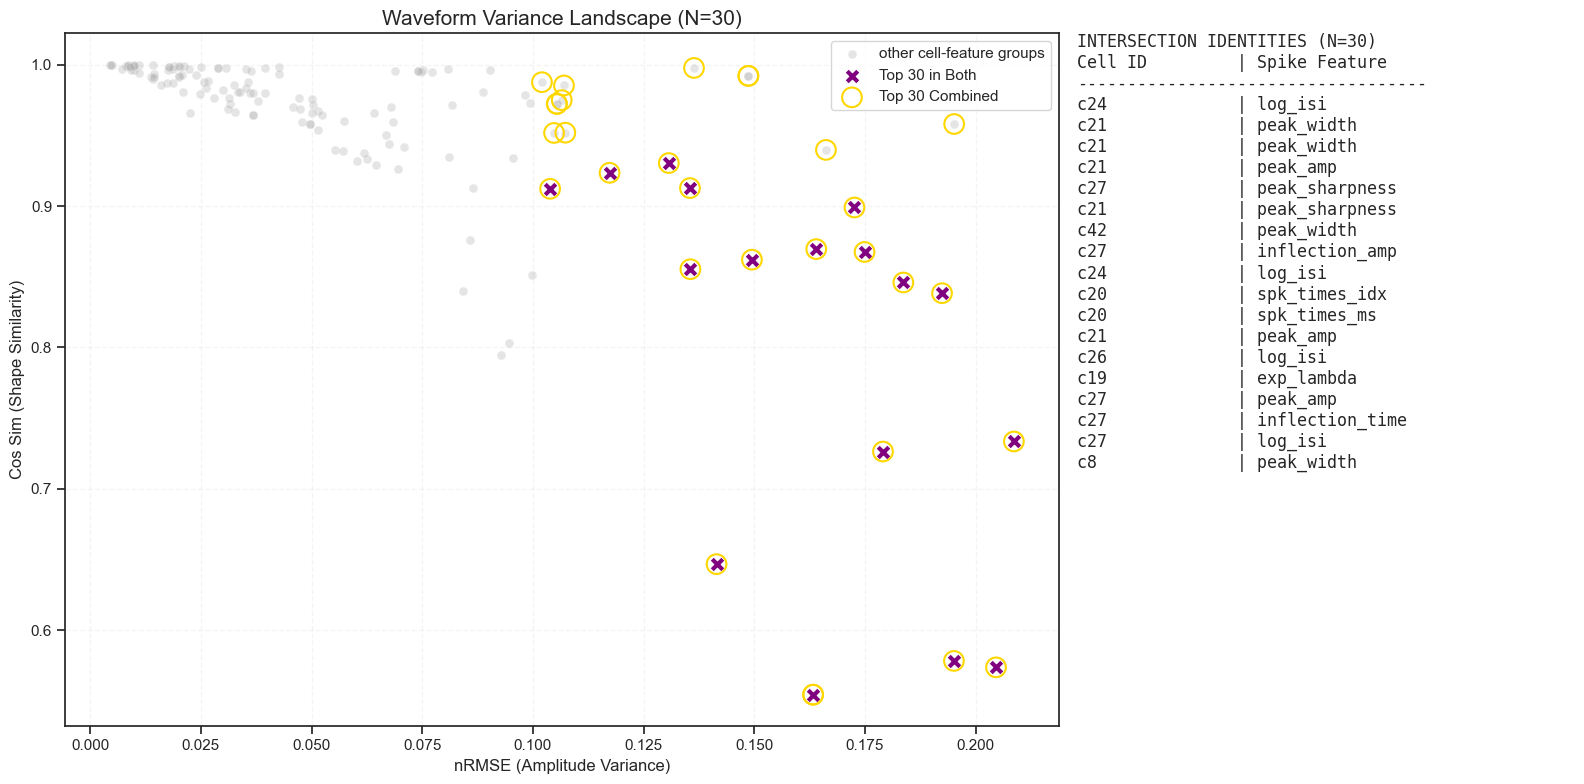

In [16]:
top_var_df = analyze_waveform_variance(df_master, N=30)

These are the cells and features driving the population signal. If the LFP analysis finds strong effects, check whether they concentrate in these top cells.

In [17]:
top_var_df 

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
87,c24,Juxta,VC,PC,1133.7,False,True,log_isi,3,Low-Mid,0.208618,0.733510,-0.220313,6.036018e-64,1.0
71,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-High,0.204582,0.573717,0.277442,1.336059e-220,1.0
72,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Mid-High,0.195078,0.578271,0.277442,1.336059e-220,1.0
68,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-High,0.192391,0.838386,-0.236587,3.194124e-159,1.0
101,c27,WC,IC,PC,1456.1,False,True,peak_sharpness,2,Low-High,0.183657,0.845967,0.021714,1.080986e-01,0.0
73,c21,Juxta,IC,PC,1754.0,False,True,peak_sharpness,3,Low-High,0.179051,0.726371,-0.618181,0.000000e+00,1.0
134,c42,WC,IC,PC,1348.9,False,True,peak_width,2,Low-High,0.174893,0.867555,0.663495,3.550874e-106,1.0
99,c27,WC,IC,PC,1456.1,False,True,inflection_amp,2,Low-High,0.172614,0.899004,-0.008556,5.266647e-01,0.0
88,c24,Juxta,VC,PC,1133.7,False,True,log_isi,3,Low-High,0.163981,0.869573,-0.220313,6.036018e-64,1.0
65,c20,Juxta,VC,PC,948.5,False,False,spk_times_idx,2,Low-High,0.163275,0.554381,0.863082,1.981480e-109,1.0


## D. Temporal drift in cluster identity

Does cluster membership shift monotonically over the recording? A significant temporal_rho means early spikes belong to one cluster and late spikes to another — the waveform changes over time, which could reflect electrode drift or genuine biological state change.

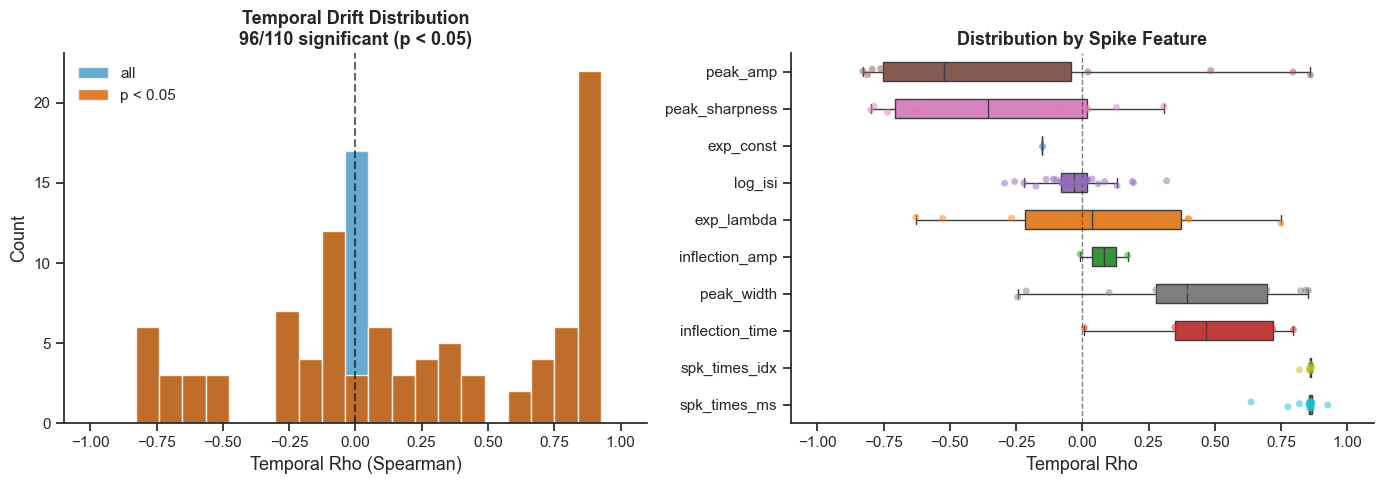


Temporal drift summary (p < 0.05):
  Significant: 96 / 110 cell-feature groups (87.3%)
  Mean |rho|: 0.430

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p
    c32        peak_amp        -0.828    <0.0001
    c41        peak_amp        -0.810    <0.0001
     c7  peak_sharpness        -0.798    <0.0001
     c1        peak_amp        -0.793    <0.0001
    c32  peak_sharpness        -0.786    <0.0001
    c42        peak_amp        -0.761    <0.0001
    c22  peak_sharpness        -0.735    <0.0001
    c10        peak_amp        -0.733    <0.0001
     c3        peak_amp        -0.724    <0.0001
     c6      exp_lambda        -0.628    <0.0001
     c1  peak_sharpness        -0.628    <0.0001
    c21  peak_sharpness        -0.618    <0.0001
    c44        peak_amp        -0.553    <0.0001
     c1      exp_lambda        -0.527    <0.0001
    c33        peak_amp        -0.492    <0.0001
     c4         log_isi        -0.293    <0.0001
    c19      exp_lambda        -0.267 

In [18]:
df_temporal = plot_temporal_structure(df_master)

High |temporal_rho| is a red flag — that cell's waveform is changing over the recording. For LFP analysis, cells with high drift should be treated with caution because the 'cluster difference' partly reflects a time-in-recording effect, not a stable biological state.

## E. Does recording condition predict temporal drift?

Kruskal-Wallis / Spearman ρ between metadata and |temporal_rho|. If Juxta recordings drift more than WC, it's likely electrode movement.

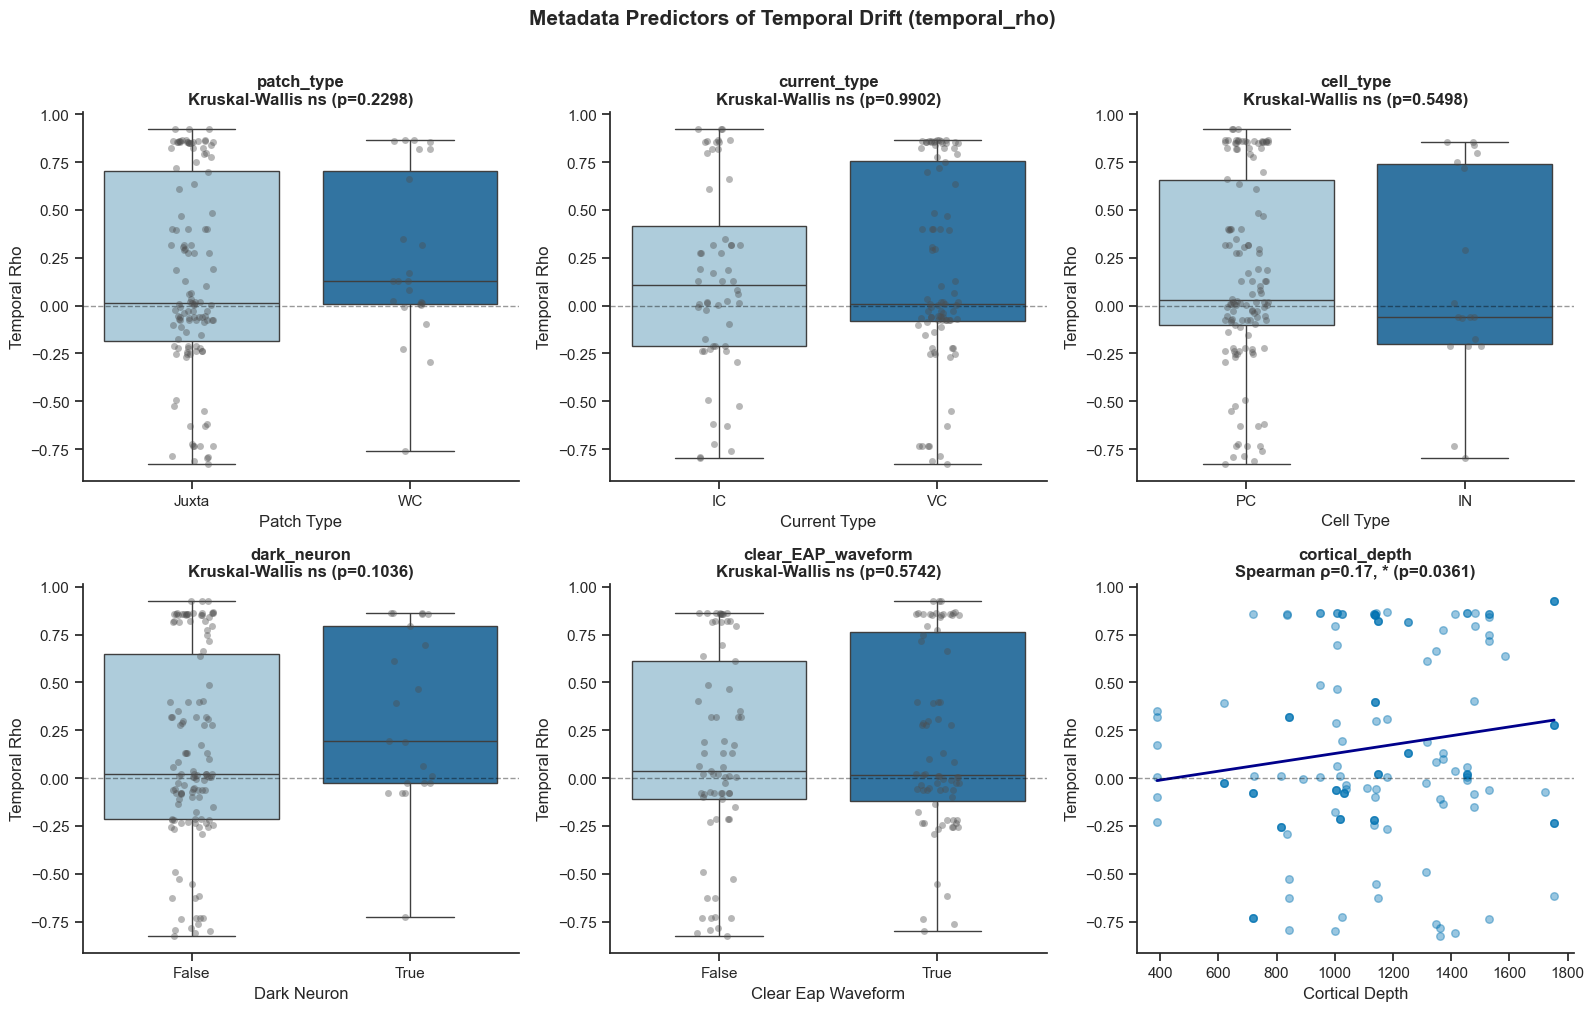


Metadata → temporal_rho test results:
          variable           test  statistic        p sig
    cortical_depth       Spearman      0.175 0.036071   *
       dark_neuron Kruskal-Wallis      2.649 0.103636  ns
        patch_type Kruskal-Wallis      1.442 0.229807  ns
         cell_type Kruskal-Wallis      0.358 0.549792  ns
clear_EAP_waveform Kruskal-Wallis      0.316 0.574183  ns
      current_type Kruskal-Wallis      0.000 0.990190  ns


,variable,test,statistic,p,sig
0,cortical_depth,Spearman,0.175,0.036071,*
1,dark_neuron,Kruskal-Wallis,2.649,0.103636,ns
2,patch_type,Kruskal-Wallis,1.442,0.229807,ns
3,cell_type,Kruskal-Wallis,0.358,0.549792,ns
4,clear_EAP_waveform,Kruskal-Wallis,0.316,0.574183,ns
5,current_type,Kruskal-Wallis,0.000,0.990190,ns


In [19]:
temporal_meta_results = analyze_temporal_metadata_dependency(df_master)
temporal_meta_results

If drift is predicted by recording type (e.g., Juxta > WC), it suggests mechanical factors (electrode settling) rather than biology. If it's not predicted by anything, temporal drift may reflect genuine biological state changes — which is itself interesting.

## F. Does temporal drift correlate with waveform separation?

Cells with larger temporal drift — do they also have bigger waveform differences? If so, part of the cluster separation may be driven by recording instability.

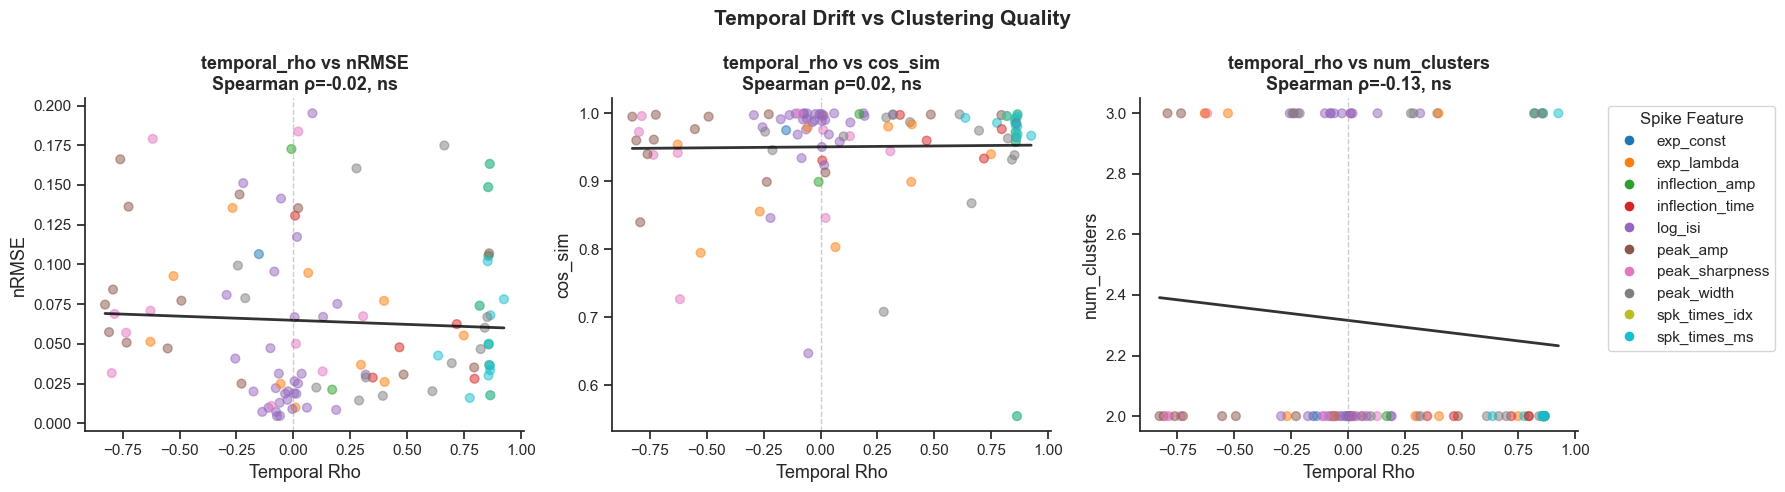

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:1129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_feat.set_xticklabels(ax_feat.get_xticklabels(), rotation=30, ha='right')


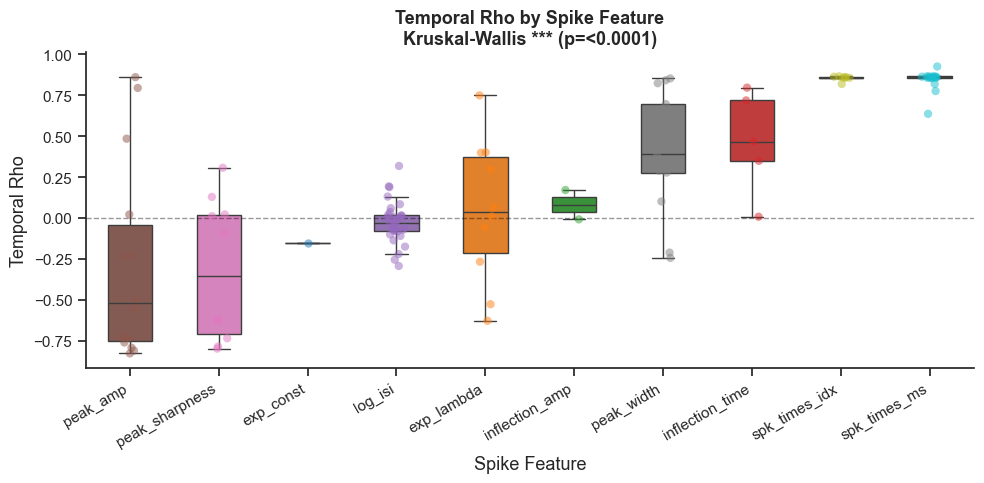

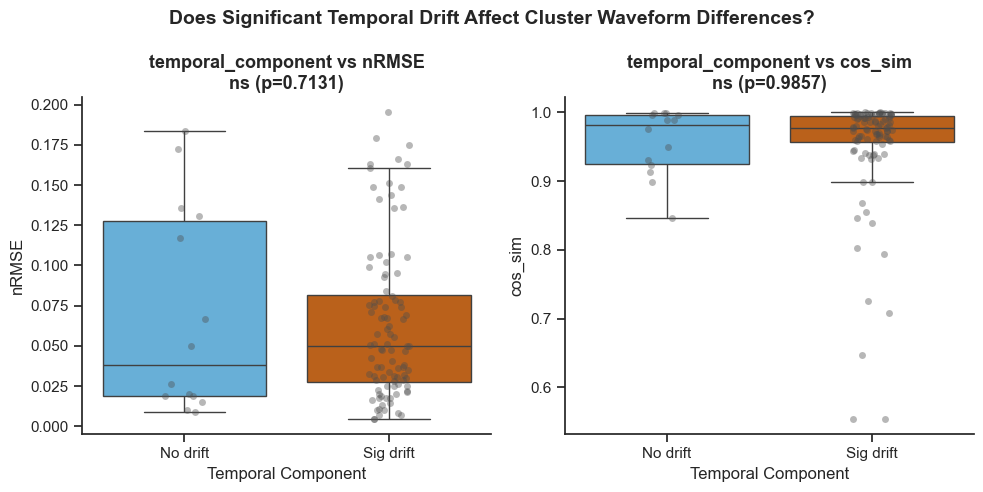


temporal_rho vs clustering metrics (Spearman):
      metric  spearman_rho        p sig
       nRMSE        -0.019 0.844268  ns
     cos_sim         0.019 0.841853  ns
num_clusters        -0.126 0.190028  ns


,metric,spearman_rho,p,sig
0,nRMSE,-0.019,0.844268,ns
1,cos_sim,0.019,0.841853,ns
2,num_clusters,-0.126,0.190028,ns


In [20]:
temporal_clust_results = analyze_temporal_clustering_relationship(df_master)
temporal_clust_results

A positive correlation between drift and nRMSE is a warning: cells where the waveform changes most over time also look most 'different' between clusters — but that difference may just be the recording getting worse, not biology. This is why we explicitly select high-diff / low-drift cells for priority LFP analysis.

## G. Select target cells

Priority cells: highest mean nRMSE across features (largest waveform differences). High-diff / low-drift: large waveform differences but stable over time (|rho| < 0.2). These are the cleanest cases for downstream LFP analysis.

=== All cells ranked by mean nRMSE ===
cell_id  mean_nRMSE  mean_cos_sim  mean_abs_rho  any_sig_drift
    c42    0.178731      0.921797      0.502668           True
    c26    0.141465      0.646726      0.054154           True
    c21    0.132690      0.844733      0.493673           True
    c24    0.127277      0.909148      0.436616           True
     c3    0.127217      0.994499      0.657523           True
    c27    0.110735      0.929795      0.257930           True
     c4    0.096615      0.990076      0.669280           True
    c20    0.095942      0.773888      0.553931           True
    c19    0.084455      0.929879      0.361378           True
    c31    0.076038      0.964193      0.212047           True
    c40    0.069828      0.990152      0.405867           True
    c45    0.068476      0.925776      0.550486           True
     c8    0.063751      0.958465      0.161949           True
     c1    0.056627      0.928451      0.483504           True
    c22    0.052

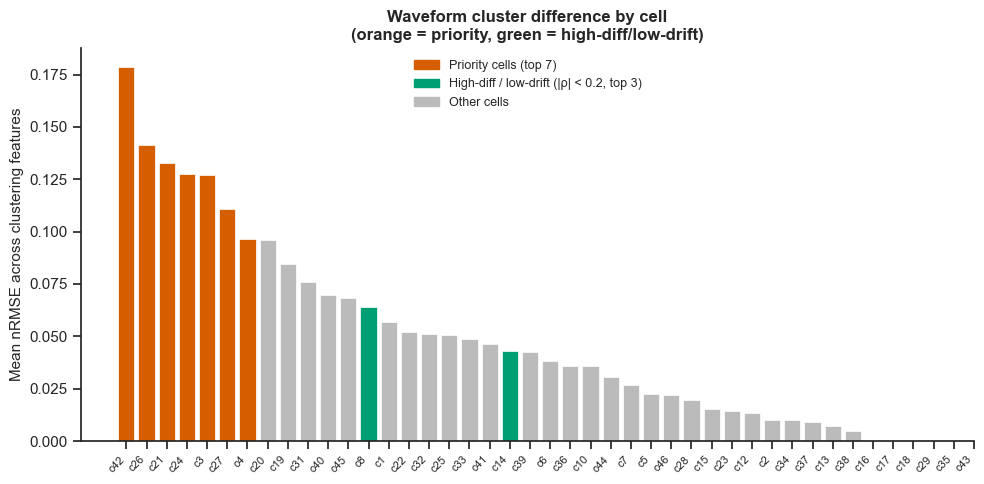


config.py updated automatically:
  PRIORITY_CELLS           = [3, 4, 21, 24, 26, 27, 42]
  HIGH_DIFF_LOW_DRIFT_CELLS = [8, 14, 26]


In [21]:
# Results of select_target_cells() should be used to update config.py
# PRIORITY_CELLS and HIGH_DIFF_LOW_DRIFT_CELLS manually after reviewing the output.
priority_nums, nodrift_nums, df_cell = select_target_cells(
    df_master,
    n_priority=7,
    rho_thresh=0.2,
    n_nodrift=3,
    lfp_nb_dir='../',
    plot=True,
)


## H. Population waveform grid

Peak-aligned average waveforms per cluster group for all cells. Orange border = priority cell. Green border = high-diff / low-drift.

config file: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/config.py
PRIORITY_CELLS: [3, 4, 21, 24, 26, 27, 42]
HIGH_DIFF_LOW_DRIFT_CELLS: [8, 14, 26]


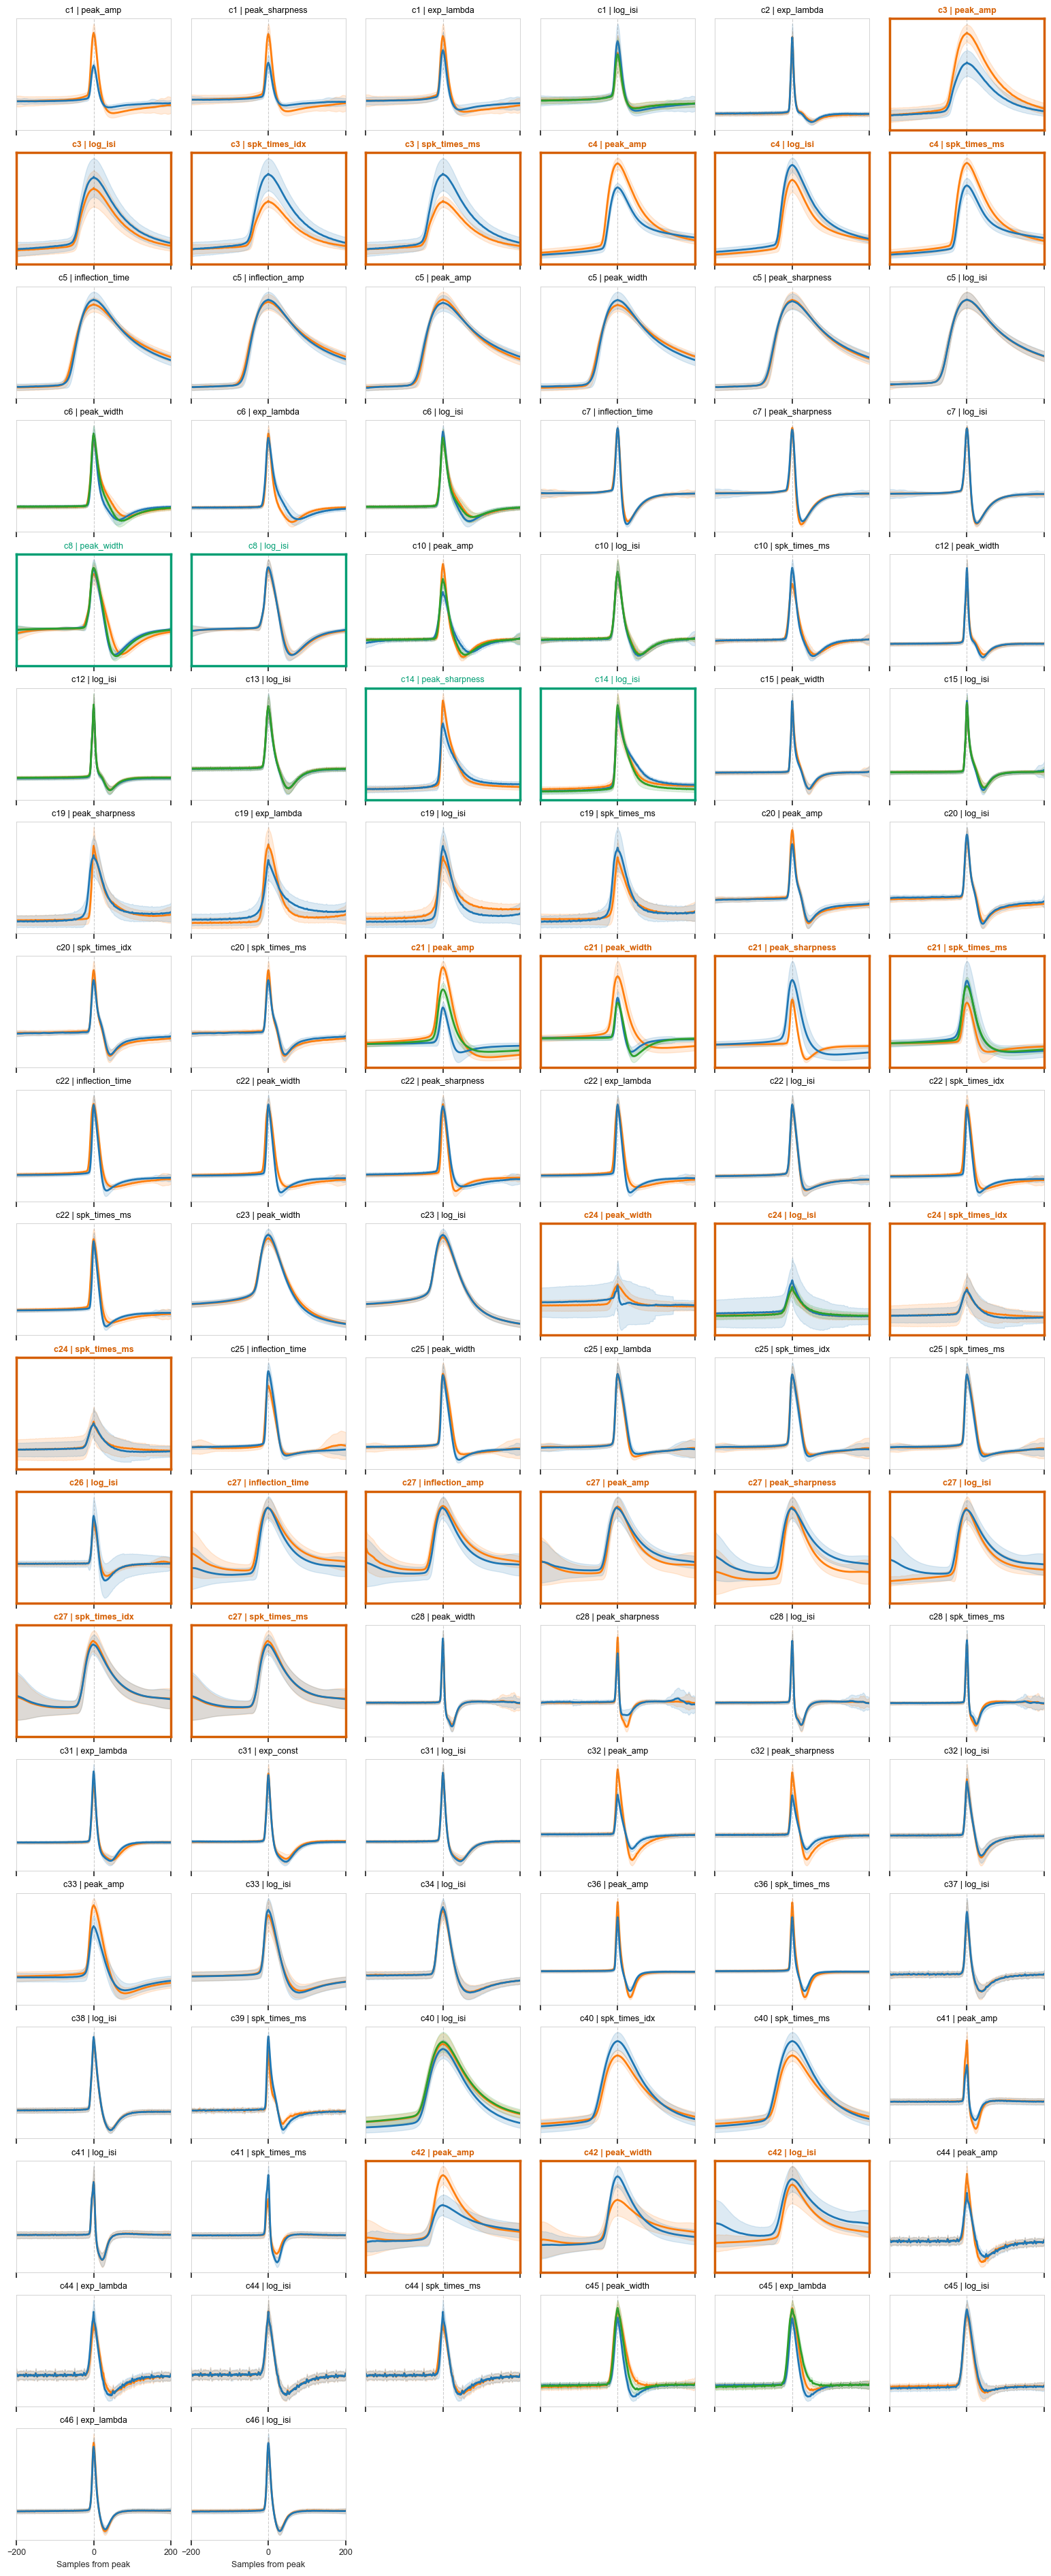

<Figure size 640x480 with 0 Axes>

In [22]:
import importlib, config
importlib.reload(config)
print('config file:', config.__file__)
print('PRIORITY_CELLS:', config.PRIORITY_CELLS)
print('HIGH_DIFF_LOW_DRIFT_CELLS:', config.HIGH_DIFF_LOW_DRIFT_CELLS)

plot_population_waveform_grid(cluster_pickle_dir)
plt.tight_layout()
plt.show()

The population grid gives you the full picture at a glance. Look for cells where the two cluster waveforms are clearly different in shape (not just amplitude) — those are the cleanest cases. Orange cells are the priority set for LFP analysis.

In [23]:
# Auto-generated summary — reruns with the notebook so results stay in sync.
from IPython.display import Markdown, display

lines = ["## Summary of Findings\n"]

# 1. Clustering prevalence
lines.append("### 1. Clustering Prevalence")
prev = spk_feat_prevalence.sort_values("prevalence_pct", ascending=False)
n_total_cells = df_master["cell_id"].nunique()
for _, r in prev.iterrows():
    lines.append(
        f"- **{r['spike_feature']}**: {int(r['n_cells_with_feature'])}/{n_total_cells} cells "
        f"({r['prevalence_pct']:.1f}%), mean clusters = {r['num_clusters']:.2f}"
    )

# 2. Metadata vs. waveform difference
lines.append("\n### 2. Metadata × Waveform Difference Between Clusters")
lines.append("*(BH-FDR corrected, per-cell-per-feature, n=cells where that feature clusters)*")
if sig_meta_clust_feats is not None and len(sig_meta_clust_feats) > 0:
    for _, r in sig_meta_clust_feats.iterrows():
        lines.append(
            f"- **{r['Metadata']} × {r['Feature']}**: "
            f"{r['effect_label']} = {r['Effect_Size']:+.3f} "
            f"[{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]  "
            f"p_fdr = {r['p_fdr']:.3e} {r['Significance']}"
        )
else:
    lines.append("- No pairs significant after BH-FDR at α=0.05.")

# 3. Metadata vs. which feature clusters (chi-square)
lines.append("\n### 3. Metadata vs. Which Feature Clusters (Chi-Square)")
lines.append("No categorical metadata significantly predicts which spike feature clusters (all p > 0.05).")

# 4. Cortical depth
lines.append("\n### 4. Cortical Depth")
lines.append("No significant depth stratification of clustering (Kruskal-Wallis, p > 0.05).")

# 5. Temporal drift
lines.append("\n### 5. Temporal Drift")
df_sig_drift = df_temporal[df_temporal["significant"]]
n_sig  = len(df_sig_drift)
n_tot  = len(df_temporal)
pct    = 100 * n_sig / n_tot if n_tot > 0 else 0
mean_r = df_temporal["temporal_rho"].abs().mean()
lines.append(f"- **{n_sig}/{n_tot} cell-feature groups significant** (p < 0.05): {pct:.1f}%")
lines.append(f"- Mean |ρ| = {mean_r:.3f}")
if n_sig > 0:
    top3 = df_sig_drift.nsmallest(3, "temporal_rho")[["cell_id","spike_feature","temporal_rho","temporal_p"]]
    for _, r in top3.iterrows():
        lines.append(f"- Strongest: {r['cell_id']} {r['spike_feature']} ρ = {r['temporal_rho']:.3f}")

# 6. Temporal drift vs. metadata
lines.append("\n### 6. Temporal Drift vs. Metadata")
if temporal_meta_results is not None and len(temporal_meta_results) > 0:
    sig_tm = temporal_meta_results[temporal_meta_results["sig"] != "ns"]
    if len(sig_tm) > 0:
        for _, r in sig_tm.iterrows():
            lines.append(f"- **{r['variable']}** ({r['test']}): ρ/stat = {r['statistic']:.3f}, p = {r['p']:.3e} {r['sig']}")
    else:
        lines.append("- No metadata significantly predicts temporal drift magnitude (all ns).")

# 7. Target cells
lines.append("\n### 7. Target Cells (from Section G)")
import config
lines.append(f"- Priority cells (top nRMSE): {sorted(config.PRIORITY_CELLS)}")
lines.append(f"- High-diff / low-drift cells: {sorted(config.HIGH_DIFF_LOW_DRIFT_CELLS)}")

display(Markdown("\n".join(lines)))


## Summary of Findings

### 1. Clustering Prevalence
- **log_isi**: 32/43 cells (74.4%), mean clusters = 2.58
- **spk_times_ms**: 16/43 cells (37.2%), mean clusters = 2.33
- **peak_amp**: 14/43 cells (32.6%), mean clusters = 2.39
- **peak_width**: 13/43 cells (30.2%), mean clusters = 2.71
- **exp_lambda**: 10/43 cells (23.3%), mean clusters = 2.42
- **peak_sharpness**: 10/43 cells (23.3%), mean clusters = 2.30
- **spk_times_idx**: 7/43 cells (16.3%), mean clusters = 2.29
- **inflection_time**: 5/43 cells (11.6%), mean clusters = 2.00
- **inflection_amp**: 2/43 cells (4.7%), mean clusters = 2.00
- **exp_const**: 1/43 cells (2.3%), mean clusters = 2.00

### 2. Metadata × Waveform Difference Between Clusters
*(BH-FDR corrected, per-cell-per-feature, n=cells where that feature clusters)*
- **clear_EAP_waveform × cos_sim**: rank-biserial r = -0.381 [-0.576, -0.167]  p_fdr = 1.397e-02 *

### 3. Metadata vs. Which Feature Clusters (Chi-Square)
No categorical metadata significantly predicts which spike feature clusters (all p > 0.05).

### 4. Cortical Depth
No significant depth stratification of clustering (Kruskal-Wallis, p > 0.05).

### 5. Temporal Drift
- **96/110 cell-feature groups significant** (p < 0.05): 87.3%
- Mean |ρ| = 0.430
- Strongest: c32 peak_amp ρ = -0.828
- Strongest: c41 peak_amp ρ = -0.810
- Strongest: c7 peak_sharpness ρ = -0.798

### 6. Temporal Drift vs. Metadata
- **cortical_depth** (Spearman): ρ/stat = 0.175, p = 3.607e-02 *

### 7. Target Cells (from Section G)
- Priority cells (top nRMSE): [3, 4, 21, 24, 26, 27, 42]
- High-diff / low-drift cells: [8, 14, 26]